In [2]:
from google.colab import files

uploaded = files.upload()

Saving train_u6lujuX_CVtuZ9i.csv to train_u6lujuX_CVtuZ9i.csv


In [3]:
import pandas as pd

df = pd.read_csv('train_u6lujuX_CVtuZ9i.csv')
print(df.head())

    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History Property_Area Loan_Status  
0             1.0         Urban           Y  
1             1.0         Rural           N  
2             1.0   

In [4]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

Shape: (614, 13)

Columns:
Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

Missing Values:
Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64


In [5]:
# Fill categorical columns with mode

df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)
df['Married'].fillna(df['Married'].mode()[0], inplace=True)
df['Dependents'].fillna(df['Dependents'].mode()[0], inplace=True)
df['Self_Employed'].fillna(df['Self_Employed'].mode()[0], inplace=True)

# Fill numerical columns with median

df['LoanAmount'].fillna(df['LoanAmount'].median(), inplace=True)
df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].median(), inplace=True)
df['Credit_History'].fillna(df['Credit_History'].median(), inplace=True)

print(df.isnull().sum())

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64


/tmp/ipykernel_2110/3681645824.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)
/tmp/ipykernel_2110/3681645824.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=Tru

In [6]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,0,1,0,0,0,0,5849,0.0,128.0,360.0,1.0,2,1
1,1,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,0
2,2,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2,1
3,3,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2,1
4,4,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,2,1


In [7]:
X = df.drop('Loan_Status', axis=1)

y = df['Loan_Status']

print(X.shape)
print(y.shape)

(614, 12)
(614,)


In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (491, 12)
Testing Data: (123, 12)


In [9]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("Logistic Regression Trained Successfully")

Logistic Regression Trained Successfully


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [10]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("Decision Tree Trained Successfully")

Decision Tree Trained Successfully


In [11]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest Trained Successfully")

Random Forest Trained Successfully


In [12]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

def evaluate_model(name, y_true, y_pred):

    print("\n", "="*40)
    print(name)
    print("="*40)

    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall   :", recall_score(y_true, y_pred))
    print("F1 Score :", f1_score(y_true, y_pred))
    print("ROC-AUC  :", roc_auc_score(y_true, y_pred))

In [13]:
evaluate_model(
    "Logistic Regression",
    y_test,
    lr_pred
)

evaluate_model(
    "Decision Tree",
    y_test,
    dt_pred
)

evaluate_model(
    "Random Forest",
    y_test,
    rf_pred
)


Logistic Regression
Accuracy : 0.7886178861788617
Precision: 0.7596153846153846
Recall   : 0.9875
F1 Score : 0.8586956521739131
ROC-AUC  : 0.7030523255813954

Decision Tree
Accuracy : 0.6910569105691057
Precision: 0.75
Recall   : 0.7875
F1 Score : 0.7682926829268293
ROC-AUC  : 0.6495639534883721

Random Forest
Accuracy : 0.7804878048780488
Precision: 0.7572815533980582
Recall   : 0.975
F1 Score : 0.8524590163934426
ROC-AUC  : 0.6968023255813953


In [14]:
# Remove Loan_ID because it is just an identifier

X = df.drop(['Loan_ID', 'Loan_Status'], axis=1)

y = df['Loan_Status']

print(X.shape)
print(y.shape)

(614, 11)
(614,)


In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Scaling Complete")

Scaling Complete


In [17]:
from sklearn.linear_model import LogisticRegression

lr_improved = LogisticRegression(
    C=10,
    max_iter=2000,
    random_state=42
)

lr_improved.fit(
    X_train_scaled,
    y_train
)

lr_improved_pred = lr_improved.predict(
    X_test_scaled
)

print("Improved Logistic Regression Trained")

Improved Logistic Regression Trained


In [18]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Accuracy :", accuracy_score(y_test, lr_improved_pred))
print("Precision:", precision_score(y_test, lr_improved_pred))
print("Recall   :", recall_score(y_test, lr_improved_pred))
print("F1 Score :", f1_score(y_test, lr_improved_pred))
print("ROC AUC  :", roc_auc_score(y_test, lr_improved_pred))

Accuracy : 0.7886178861788617
Precision: 0.7596153846153846
Recall   : 0.9875
F1 Score : 0.8586956521739131
ROC AUC  : 0.7030523255813954


In [19]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:")
print(grid.best_params_)

print("\nBest Cross Validation Score:")
print(grid.best_score_)

Best Parameters:
{'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 100}

Best Cross Validation Score:
0.812533498247784


In [20]:
best_rf = RandomForestClassifier(
    max_depth=5,
    min_samples_split=2,
    n_estimators=100,
    random_state=42
)

best_rf.fit(X_train, y_train)

best_rf_pred = best_rf.predict(X_test)

print("Accuracy :", accuracy_score(y_test, best_rf_pred))
print("Precision:", precision_score(y_test, best_rf_pred))
print("Recall   :", recall_score(y_test, best_rf_pred))
print("F1 Score :", f1_score(y_test, best_rf_pred))
print("ROC AUC  :", roc_auc_score(y_test, best_rf_pred))

Accuracy : 0.7804878048780488
Precision: 0.7572815533980582
Recall   : 0.975
F1 Score : 0.8524590163934426
ROC AUC  : 0.6968023255813953


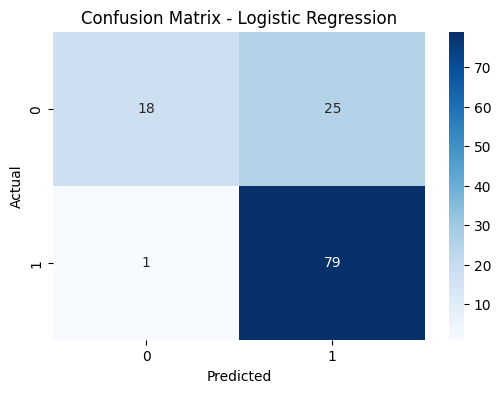

In [21]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

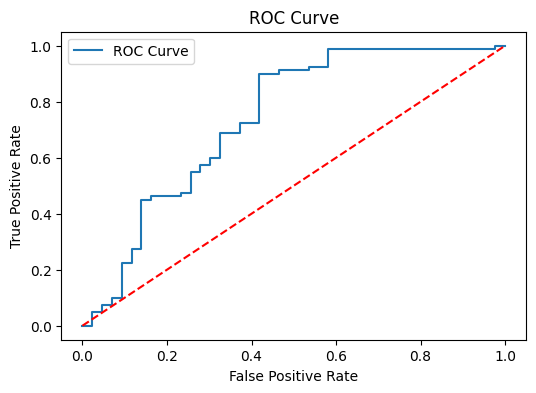

In [23]:
from sklearn.metrics import roc_curve

y_prob = lr_improved.predict_proba(X_test_scaled)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label='ROC Curve')
plt.plot([0,1],[0,1],'r--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()

plt.show()

In [26]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr_improved.coef_[0]
})

importance = importance.sort_values(
    by='Coefficient',
    ascending=False
)

importance

,Feature,Coefficient
9,Credit_History,1.340360
1,Married,0.319340
2,Dependents,0.120884
10,Property_Area,0.079203
4,Self_Employed,0.051288
8,Loan_Amount_Term,0.046837
5,ApplicantIncome,-0.026293
0,Gender,-0.070324
6,CoapplicantIncome,-0.153689
3,Education,-0.162175


In [28]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance.head(10)

,Feature,Importance
9,Credit_History,0.543174
5,ApplicantIncome,0.096050
7,LoanAmount,0.095240
6,CoapplicantIncome,0.072758
8,Loan_Amount_Term,0.065654
10,Property_Area,0.039486
2,Dependents,0.026706
1,Married,0.025326
4,Self_Employed,0.014306
3,Education,0.013505


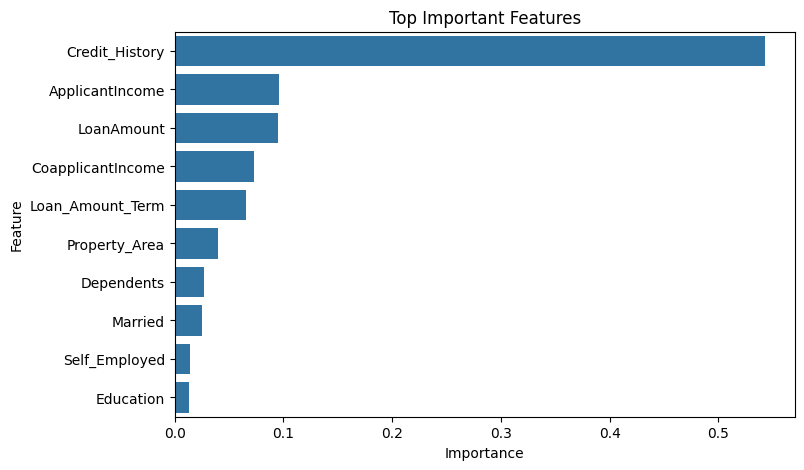

In [29]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance.head(10)
)

plt.title('Top Important Features')

plt.show()

In [30]:
!pip freeze > requirements.txt

In [31]:
from google.colab import files

files.download('requirements.txt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>